In [11]:
import os
from google.cloud import vision
import pandas as pd
import re
import matplotlib.pyplot as plt
import cv2

In [12]:
# Set the environment variable
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r'**********'    #secret key is hidden You can use by extracting
client = vision.ImageAnnotatorClient()

image_path = 'dataset/prescription_5.png'
folder_path = 'dataset'

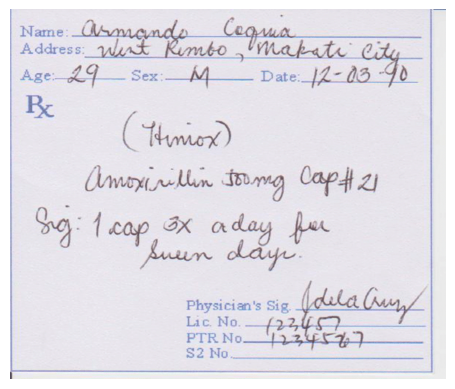

In [13]:
image = image= cv2.imread(image_path)


# Convert BGR to RGB (OpenCV uses BGR by default)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image using matplotlib
plt.imshow(image_rgb)
plt.axis('off')  # Turn off axis labels
plt.show()

### Confidence in detecting words:

In [14]:


def detect_document(path):
    """Detects document features in an image."""
    # Use the service account file for authentication
    client = vision.ImageAnnotatorClient.from_service_account_file(os.environ["GOOGLE_APPLICATION_CREDENTIALS"])

    with open(path, "rb") as image_file:
        content = image_file.read()
    image = vision.Image(content=content)
    response = client.document_text_detection(image=image)

    for page in response.full_text_annotation.pages:
        for block in page.blocks:
            print(f"\nBlock confidence: {block.confidence}\n")
            for paragraph in block.paragraphs:
                print("Paragraph confidence: {}".format(paragraph.confidence))
                for word in paragraph.words:
                    word_text = "".join([symbol.text for symbol in word.symbols])
                    print(
                        "Word text: {} (confidence: {})".format(
                            word_text, word.confidence
                        )
                    )
                    for symbol in word.symbols:
                        print(
                            "\tSymbol: {} (confidence: {})".format(
                                symbol.text, symbol.confidence
                            )
                        )
    if response.error.message:
        raise Exception(
            "{}\nFor more info on error messages, check: "
            "https://cloud.google.com/apis/design/errors".format(response.error.message)
        )

In [15]:
detect_document(image_path)


Block confidence: 0.7479345798492432

Paragraph confidence: 0.7479345798492432
Word text: Name (confidence: 0.94444739818573)
	Symbol: N (confidence: 0.9578179717063904)
	Symbol: a (confidence: 0.9623527526855469)
	Symbol: m (confidence: 0.9404948353767395)
	Symbol: e (confidence: 0.9171240329742432)
Word text: : (confidence: 0.8700349926948547)
	Symbol: : (confidence: 0.8700349926948547)
Word text: Armando (confidence: 0.6181986331939697)
	Symbol: A (confidence: 0.4814620912075043)
	Symbol: r (confidence: 0.624260663986206)
	Symbol: m (confidence: 0.6292675137519836)
	Symbol: a (confidence: 0.6542218327522278)
	Symbol: n (confidence: 0.6700310707092285)
	Symbol: d (confidence: 0.777457594871521)
	Symbol: o (confidence: 0.4906896650791168)

Block confidence: 0.8545634746551514

Paragraph confidence: 0.8545634746551514
Word text: Cogna (confidence: 0.6499068737030029)
	Symbol: C (confidence: 0.7598642706871033)
	Symbol: o (confidence: 0.6683998107910156)
	Symbol: g (confidence: 0.55817

### Detected text

In [16]:
# Uncleaned data

from google.cloud import vision_v1

# Set up Google Cloud Vision API client
client = vision_v1.ImageAnnotatorClient()

# Check without improved resolution
with open(image_path, "rb") as image_file:
    content = image_file.read()

image = vision_v1.Image(content=content)

response = client.text_detection(image=image)

texts = response.text_annotations

# Extract raw text without data cleaning
raw_text = [text.description for text in texts if text.locale.lower() == 'en']

# Print the raw text
print(raw_text[0])

Name: Armando
Cogna
Address: West Rimbo, Makati City
Age: 29 Sex: M Date: 12-03-90
Px
(Hinox)
Amoxicillin Joong Cap #21
Sigj: 1 cap 3x a day for
Sween days.
Physician's Sig.
delay
Lic. No. 123457
PTR No. 127458467
$2 No.


In [17]:
# Correct one


#Check without improved resolution

from google.cloud import vision_v1

# Set up Google Cloud Vision API client
client = vision_v1.ImageAnnotatorClient()

# Check without improved resolution
with open(image_path, "rb") as image_file:
    content = image_file.read()

image = vision_v1.Image(content=content)

response = client.text_detection(image=image)

texts = response.text_annotations

# Create an empty list to store dictionaries
data = []

for text in texts:
    data.append({
        'locale': text.locale,
        'description': text.description
    })

# Extract only English text and numbers
cleaned_data = []
for item in data:
    if item['locale'].lower() == 'en':
        # cleaned_text = re.sub(r'[^a-zA-Z0-9\s-]', '', item['description'])
        # cleaned_text = re.sub(r'[^a-zA-Z0-9\s-/]', '', item['description'])
        cleaned_text = re.sub(r'[^a-zA-Z0-9\s/-]', '', item['description'])
        cleaned_data.append(cleaned_text)

# Print the cleaned description
print(cleaned_data[0])


Name Armando
Cogna
Address West Rimbo Makati City
Age 29 Sex M Date 12-03-90
Px
Hinox
Amoxicillin Joong Cap 21
Sigj 1 cap 3x a day for
Sween days
Physicians Sig
delay
Lic No 123457
PTR No 127458467
2 No


### no need to improve resolution

In [58]:
#Improved Resolution if needed

import cv2

def improve_resolution(image_path, scale_factor):
    # Read the image
    img = cv2.imread(image_path)

    # Resize the image using interpolation
    new_width = int(img.shape[1] * scale_factor)
    new_height = int(img.shape[0] * scale_factor)
    resized_img = cv2.resize(img, (new_width, new_height), interpolation=cv2.INTER_LINEAR)

    # Save or display the improved resolution image
    cv2.imwrite("improved_resolution.jpg", resized_img)


improve_resolution(image_path, 0.8)
    

In [59]:
improved_path = 'improved_resolution.jpg'

In [60]:
from google.cloud import vision_v1
import re

# Set up Google Cloud Vision API client
client = vision_v1.ImageAnnotatorClient()

# Check without improved resolution
with open(improved_path, "rb") as image_file:
    content = image_file.read()

image = vision_v1.Image(content=content)

response = client.text_detection(image=image)

texts = response.text_annotations

# Create an empty list to store dictionaries
data = []

for text in texts:
    data.append({
        'locale': text.locale,
        'description': text.description
    })

# Extract only English text and numbers, keeping hyphens between numbers
cleaned_data = []
for item in data:
    if item['locale'].lower() == 'en':
        cleaned_text = re.sub(r'[^a-zA-Z0-9\s-]', '', item['description'])
        cleaned_data.append({'locale': item['locale'], 'description': cleaned_text})

# Store the cleaned description in a variable as a string
cleaned_description = cleaned_data[0]['description']

# Print the cleaned description
print(cleaned_description)


R
Supersize Health Center
123 Main Street Big City Upstate 12345
123 456-7890
Name Cindy Allen
Phone 123-456-7890
Address
34 Cherry Lane
Anytown USA 22222
Date 081313
DOB 022473
Prescription
Metformin 500mg
I tab PO BID 60
2 refills
Dr Best MD
Dispense as written
Substitution permissible
DEA
NPI


### Rough

In [ ]:
from drug_named_entity_recognition import find_drugs
import spacy
nlp = spacy.blank("en")
doc = nlp(cleaned_description)
output = find_drugs([t.text for t in doc], is_ignore_case=True)

In [ ]:
# Extract only the drug names
drug_names = [drug_info['name'] for drug_info, _, _ in output]

# Print the extracted drug names
print(drug_names)